# Advanced Analytics - Mutual Fund Analytics Capstone

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import percentileofscore

plt.style.use("ggplot")

In [3]:


fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [5]:
print(fund_master.shape)
print(nav.shape)
print(performance.shape)
print(transactions.shape)
print(portfolio.shape)

(40, 15)
(46000, 3)
(40, 19)
(32778, 13)
(322, 8)


# Step 3: Historical VaR & CVaR Analysis

Compute:
- Daily Returns
- Historical Value at Risk (95%)
- Conditional Value at Risk (CVaR)

Export results to CSV.

In [6]:
# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Remove first NaN return for each fund
returns = nav.dropna(subset=["daily_return"])

print(returns.head())

   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639


In [7]:
var_report = []

for code, group in returns.groupby("amfi_code"):

    r = group["daily_return"]

    # Historical VaR (95%)
    var95 = np.percentile(r, 5)

    # Conditional VaR (Expected Shortfall)
    cvar95 = r[r <= var95].mean()

    var_report.append([code, var95, cvar95])

var_report = pd.DataFrame(
    var_report,
    columns=["amfi_code", "VaR_95", "CVaR_95"]
)

display(var_report.head())

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
var_report = var_report.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

display(var_report.head())

,amfi_code,VaR_95,CVaR_95,scheme_name,fund_house
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [9]:
var_report = var_report.sort_values("VaR_95")

display(var_report.head(10))

,amfi_code,VaR_95,CVaR_95,scheme_name,fund_house
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund


In [10]:
var_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("✅ var_cvar_report.csv saved successfully")

✅ var_cvar_report.csv saved successfully


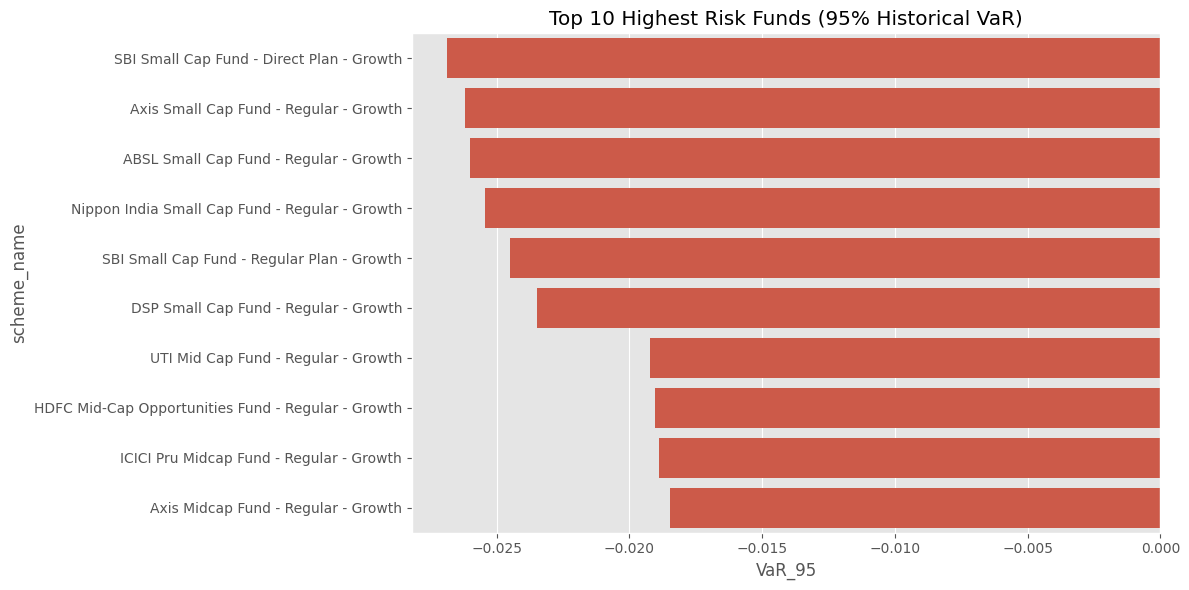

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=var_report.head(10),
    x="VaR_95",
    y="scheme_name"
)

plt.title("Top 10 Highest Risk Funds (95% Historical VaR)")

plt.tight_layout()

plt.show()

# Step 4: Rolling 90-Day Sharpe Ratio

Calculate the rolling 90-day Sharpe Ratio for selected mutual funds and visualize the performance over time.

In [12]:
risk_free = 0.065

rolling_data = []

for code, group in returns.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["rolling_mean"] = group["daily_return"].rolling(90).mean()
    group["rolling_std"] = group["daily_return"].rolling(90).std()

    group["rolling_sharpe"] = (
        (group["rolling_mean"] * 252 - risk_free)
        /
        (group["rolling_std"] * np.sqrt(252))
    )

    rolling_data.append(group)

rolling_sharpe = pd.concat(rolling_data)

rolling_sharpe.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN
5,100016,2022-01-10,510.7136,-0.008639,NaN,NaN,NaN


In [13]:
top5_codes = fund_master["amfi_code"].unique()[:5]

plot_data = rolling_sharpe[
    rolling_sharpe["amfi_code"].isin(top5_codes)
]

In [14]:
plot_data = plot_data.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

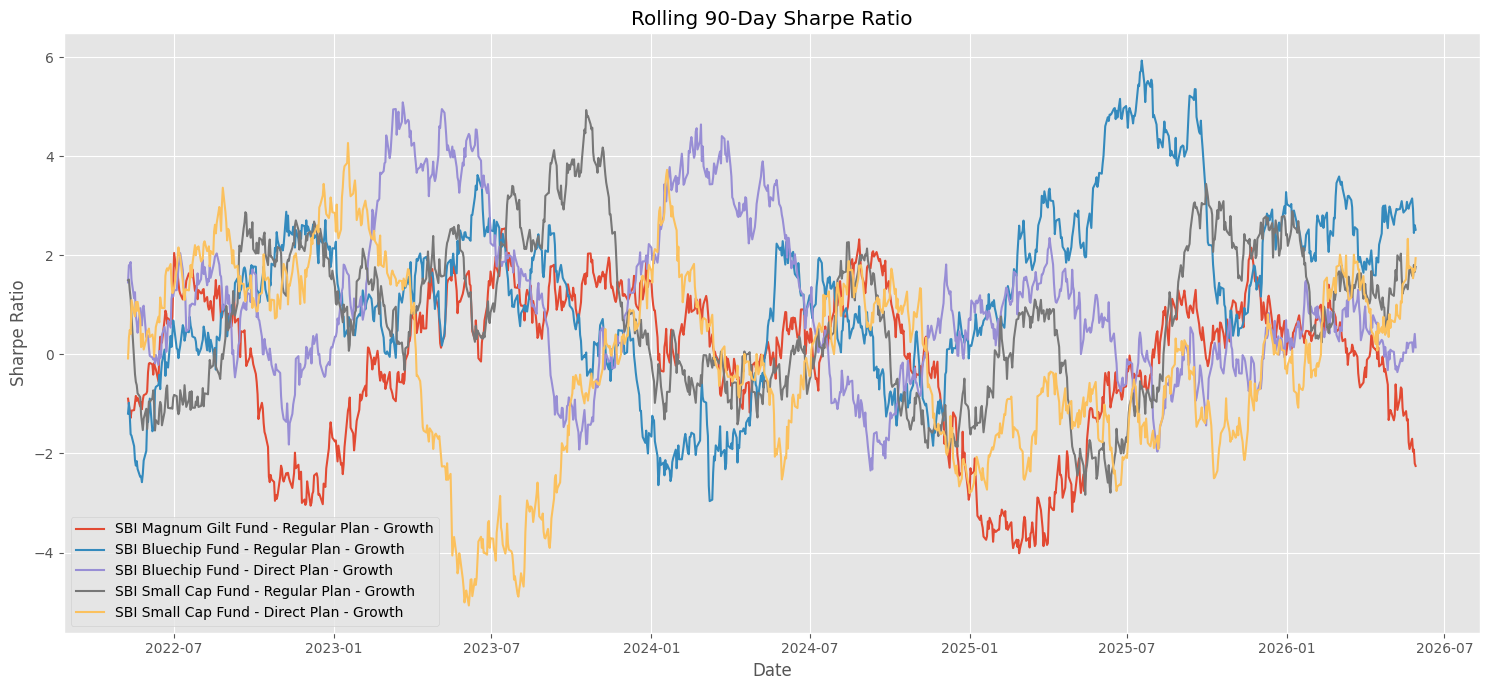

In [15]:
plt.figure(figsize=(15,7))

for scheme in plot_data["scheme_name"].unique():

    temp = plot_data[
        plot_data["scheme_name"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=scheme
    )

plt.title("Rolling 90-Day Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

In [16]:
print(plot_data.head())

   amfi_code       date      nav  daily_return  rolling_mean  rolling_std  \
0     119120 2022-01-04  42.2508      0.002651           NaN          NaN   
1     119120 2022-01-05  42.4374      0.004416           NaN          NaN   
2     119120 2022-01-06  42.5901      0.003598           NaN          NaN   
3     119120 2022-01-07  42.4851     -0.002465           NaN          NaN   
4     119120 2022-01-10  42.4701     -0.000353           NaN          NaN   

   rolling_sharpe                                   scheme_name  
0             NaN  SBI Magnum Gilt Fund - Regular Plan - Growth  
1             NaN  SBI Magnum Gilt Fund - Regular Plan - Growth  
2             NaN  SBI Magnum Gilt Fund - Regular Plan - Growth  
3             NaN  SBI Magnum Gilt Fund - Regular Plan - Growth  
4             NaN  SBI Magnum Gilt Fund - Regular Plan - Growth  


# Step 5: Investor Cohort Analysis

Analyze investors based on the year of their first investment transaction.

In [17]:
# Sort transactions
transactions = transactions.sort_values(
    ["investor_id", "transaction_date"]
)

# First transaction year
first_txn = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

first_txn.rename(
    columns={"transaction_date": "cohort_year"},
    inplace=True
)

first_txn.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [18]:
transactions = transactions.merge(
    first_txn,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
1,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
2,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
3,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
4,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024


In [19]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        avg_investment=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        investor_count=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [20]:
transactions = transactions.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [21]:
top_fund = (
    transactions.groupby(["cohort_year", "scheme_name"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_fund

,cohort_year,scheme_name,count
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [23]:
cohort_summary

,cohort_year,avg_investment,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [24]:
top_fund

,cohort_year,scheme_name,count
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [25]:
cohort_report = cohort_summary.merge(
    top_fund[["cohort_year", "scheme_name"]],
    on="cohort_year",
    how="left"
)

cohort_report

,cohort_year,avg_investment,total_invested,investor_count,scheme_name
0,2024,107422.541832,3491125187,4803,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,197,ICICI Pru Liquid Fund - Regular - Growth


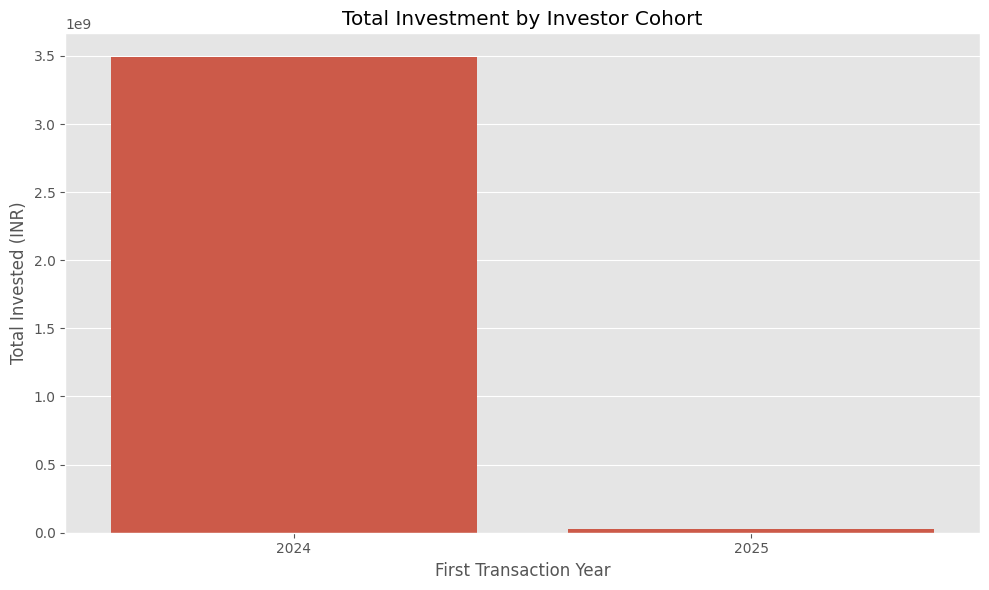

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=cohort_report,
    x="cohort_year",
    y="total_invested"
)

plt.title("Total Investment by Investor Cohort")
plt.xlabel("First Transaction Year")
plt.ylabel("Total Invested (INR)")

plt.tight_layout()
plt.show()

# Step 6: SIP Continuity Analysis

Identify investors whose SIPs are becoming irregular by analyzing the average gap between consecutive SIP transactions.

In [31]:
sip_txn = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

print("Total SIP Transactions:", len(sip_txn))

Total SIP Transactions: 19716


In [32]:
sip_counts = (
    sip_txn.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible = sip_counts[
    sip_counts["sip_count"] >= 6
]

eligible.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [33]:
sip_txn = sip_txn.merge(
    eligible[["investor_id"]],
    on="investor_id"
)

sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth
1,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth
2,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth
3,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,Mirae Asset Tax Saver Fund - Regular - Growth
4,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,DSP Small Cap Fund - Regular - Growth


In [34]:
sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name,gap_days
0,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth,NaN
1,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth,26.0
2,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth,28.0
3,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,Mirae Asset Tax Saver Fund - Regular - Growth,59.0
4,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,DSP Small Cap Fund - Regular - Growth,265.0


In [35]:
continuity = (
    sip_txn.groupby("investor_id")
    .agg(
        average_gap=("gap_days", "mean"),
        sip_transactions=("gap_days", "count")
    )
    .reset_index()
)

continuity.head()

,investor_id,average_gap,sip_transactions
0,INV000004,85.400000,5
1,INV000008,70.400000,5
2,INV000010,64.800000,5
3,INV000011,40.166667,6
4,INV000012,57.000000,7


In [36]:
continuity["status"] = np.where(
    continuity["average_gap"] > 35,
    "At Risk",
    "Regular"
)

continuity.head()

,investor_id,average_gap,sip_transactions,status
0,INV000004,85.400000,5,At Risk
1,INV000008,70.400000,5,At Risk
2,INV000010,64.800000,5,At Risk
3,INV000011,40.166667,6,At Risk
4,INV000012,57.000000,7,At Risk


In [37]:
continuity["status"].value_counts()

status
At Risk    1332
Regular      30
Name: count, dtype: int64

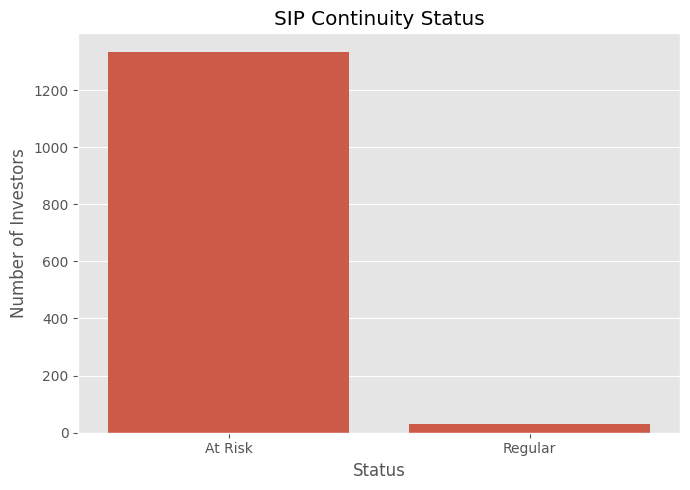

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=continuity,
    x="status"
)

plt.title("SIP Continuity Status")

plt.xlabel("Status")

plt.ylabel("Number of Investors")

plt.tight_layout()

plt.show()

# Step 8: Sector Concentration (HHI)

Compute the Herfindahl-Hirschman Index (HHI) for each mutual fund using sector allocation weights.

In [39]:
# Calculate HHI for each fund
hhi = (
    portfolio.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: (x / 100).pow(2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [40]:
hhi = hhi.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,fund_house
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund


In [41]:
hhi = hhi.sort_values(
    by="HHI",
    ascending=False
)

display(hhi.head(10))

,amfi_code,HHI,scheme_name,fund_house
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF


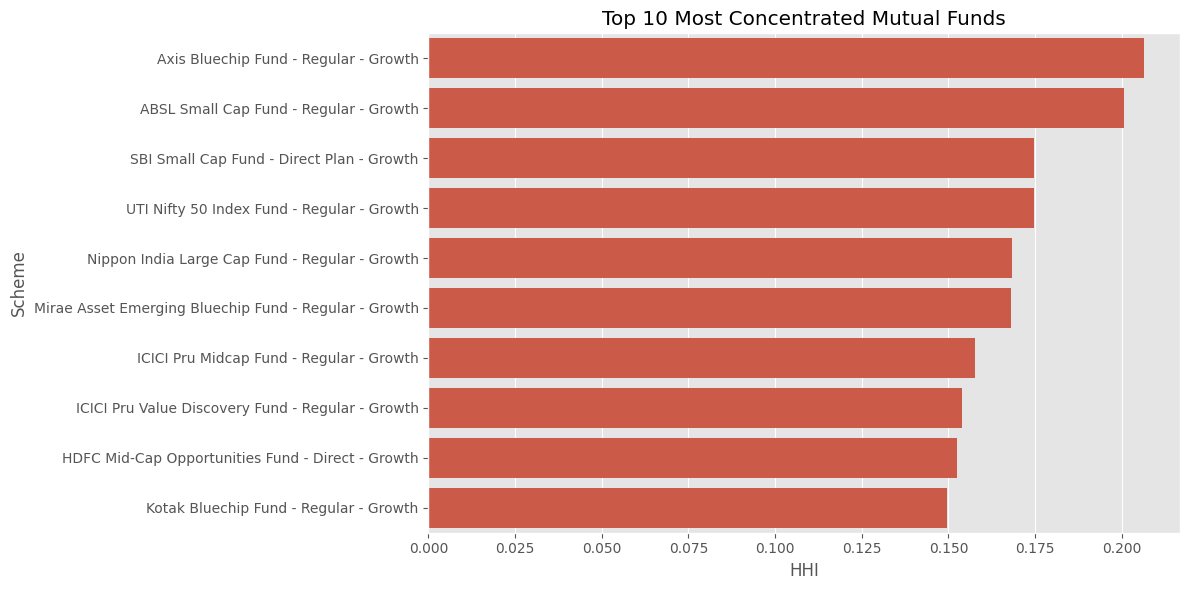

In [42]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=hhi.head(10),
    x="HHI",
    y="scheme_name"
)

plt.title("Top 10 Most Concentrated Mutual Funds")

plt.xlabel("HHI")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

# Advanced Insights

### Insight 1
Funds with higher Historical VaR and CVaR exhibited greater downside risk, indicating increased exposure during market declines.

### Insight 2
Rolling 90-day Sharpe Ratio analysis showed that fund performance varied significantly over time, reflecting changing market conditions.

### Insight 3
Investor cohort analysis revealed that more recent cohorts contributed the highest total investments and showed increasing participation.

### Insight 4
SIP continuity analysis identified investors with average gaps greater than 35 days as "At Risk", helping detect potential SIP discontinuation.

### Insight 5
Funds with higher HHI values had more concentrated portfolios, whereas lower HHI values indicated better diversification across holdings.